In [1]:
# Declare necessary libraries
import numpy as np
from src import memory
import cv2
from skimage import filters
import os
import imutils
import time
import pyproj
import matplotlib.pyplot as plt
import pandas as pd 
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import math
from mpl_toolkits.mplot3d import Axes3D 
import plotly.graph_objs as go
from scipy.interpolate import griddata
from plotly.subplots import make_subplots
import seaborn as sns
from matplotlib import font_manager
from scipy.signal import savgol_filter


In [2]:
out_folder = '/results/figures/memory_analysis'

font_path = '/usr/share/fonts/truetype/msttcorefonts/arial.ttf'
try:
    prop = font_manager.FontProperties(fname=font_path,size=7)
    print(f"Font loaded successfully: {prop.get_name()}")
except Exception as e:
    print(f"Failed to load font: {e}")


Font loaded successfully: Arial


In [3]:
# Define your parameter pairs.
N1 = 1000
N2 = 5000
N3 = 10000
N4 = 20000
N5 = 50000
N6 = 100000
N7 = 15000
param_pairs = [
    (N1, N1*0.005,8),
    (N1, N1*0.01,8),
    (N1, N1*0.02,8),
    (N1, N1*0.04,8),
    (N1, N1*0.08,8),        
    (N2, N2*0.005,8),
    (N2, N2*0.01,8),
    (N2, N2*0.02,8),
    (N2, N2*0.04,8),
    (N2, N2*0.08,8),
    (N3, N3*0.005,8),
    (N3, N3*0.01,8),
    (N3, N3*0.02,8),
    (N3, N3*0.04,8),
    (N3, N3*0.08,8),
    (N4, N4*0.005,8),
    (N4, N4*0.01,8),
    (N4, N4*0.02,8),
    (N4, N4*0.04,8),
    (N4, N4*0.08,8),
    (N5, N5*0.005,8),
    (N5, N5*0.01,8),
    (N5, N5*0.02,8),
    (N5, N5*0.04,8),
    (N5, N5*0.08,8),
    (N6, N6*0.005,8),
    (N6, N6*0.01,8),
    (N6, N6*0.02,8),
    (N6, N6*0.04,8),
    (N6, N6*0.08,8),
    (N7, N7*0.01,8),
    # Add as many as you like
]

# Define file suffixes corresponding to different types.
file_types = {
    'l': 'learning_left',
    'r': 'learning_right',
    't': 'test'
}

# Use a dictionary to store the DataFrames.
dfs = {}
src_base = '/data/processed/memory_capacity_analysis/new_for_plot_ardin/out_square_birob'


# Enumerate starting from 8, based on your original naming convention.
for i, (param1, param2, param3) in enumerate(param_pairs, start=1):
    for key, ftype in file_types.items():
        filename = f'{src_base}_{param1}_{param2}_{param3}_32_3-{ftype}.csv'
        dfs[f'df_{i}_{key}'] = pd.read_csv(filename)

# for key, ftype in file_types.items():
#     filename = f'../data/processed/memory_capacity_analysis/new_for_plot_ardin/out_rt_L_{15000}_{150}_8_32_3-{ftype}.csv'
#     dfs[f'df_{i+1}_{key}'] = pd.read_csv(filename)

In [4]:

for i, (param1, param2, param3) in enumerate(param_pairs, start=1):
    for key, ftype in file_types.items():
        filename = f'{src_base}_{param1}_{param2}_{param3}_32_3-{ftype}.csv'
        if key == 't':
            dfs[f'df_{i}_{key}']['Sign_Mismatch'] = np.where(
            dfs[f'df_{i}_{key}']['heading_error'].between(-1, 1),   # if heading_error is between -1 and 1...
            0,                                          # ...then force sign mismatch to 0,
            (np.sign(dfs[f'df_{i}_{key}']['lambda_dif']) != np.sign(dfs[f'df_{i}_{key}']['heading_error'])).astype(int)
            )
            dfs[f'df_{i}_{key}']['Cumulative_Sum'] = dfs[f'df_{i}_{key}']['Sign_Mismatch'].cumsum()
            dfs[f'df_{i}_{key}']['Cumulative_Mean'] = dfs[f'df_{i}_{key}']['Cumulative_Sum'] / (dfs[f'df_{i}_{key}'].index + 1)



In [5]:
src_out = "/results/figures/memory_analysis/"
if not os.path.exists(src_out):
    os.makedirs(src_out)
    

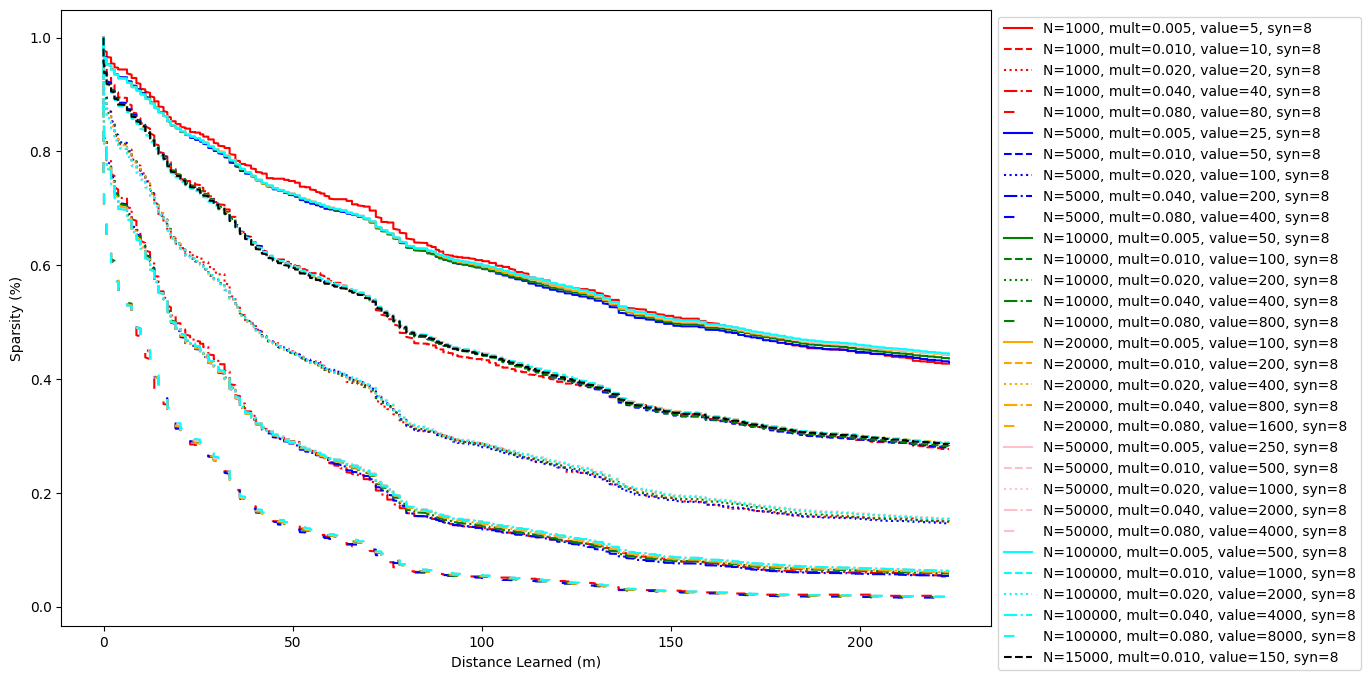

<Figure size 640x480 with 0 Axes>

In [ ]:

# Define a color for each N.
color_map = {
    N1: 'red',
    N2: 'blue',
    N3: 'green',
    N4: 'orange',
    N5: 'pink',
    N6: 'cyan'
}

# Define a linestyle for each multiplier.
# (If you want a linestyle only for a subset, just include those multipliers.
#  Here, I include one for each multiplier present in your list.)
linestyle_map = {
    0.005: '-',
    0.01: '--',
    0.02: ':',
    0.04: '-.',
    0.08: (0, (5, 10))  # Example custom dash pattern.
}


In [7]:
df

,Unnamed: 0,sparsity_L,fam_before_learn_L,timestamp,x,y,theta,local_theta,heading_error,distance,iteration_learning,img_index
0,0,1.000000,0.000000,1.057094,698420.5,4789687.5,28.90,-16.10,-45.0,0.00000,0.0,0.0
1,1,0.990000,1.000000,1.057094,698420.5,4789687.5,28.90,-11.10,-40.0,0.00000,5.0,0.0
2,2,0.984200,0.580000,1.057094,698420.5,4789687.5,28.90,-6.10,-35.0,0.00000,10.0,0.0
3,3,0.978667,0.553333,1.057094,698420.5,4789687.5,28.90,-1.10,-30.0,0.00000,15.0,0.0
4,4,0.974600,0.406667,1.057094,698420.5,4789687.5,28.90,3.90,-25.0,0.00000,20.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1355,1355,0.285800,0.000000,138.718480,698425.6,4789684.0,-52.47,-72.47,-20.0,223.58391,12310.0,135.0
1356,1356,0.285800,0.000000,138.718480,698425.6,4789684.0,-52.47,-67.47,-15.0,223.58391,12315.0,135.0
1357,1357,0.285800,0.000000,138.718480,698425.6,4789684.0,-52.47,-62.47,-10.0,223.58391,12320.0,135.0
1358,1358,0.285800,0.000000,138.718480,698425.6,4789684.0,-52.47,-57.47,-5.0,223.58391,12325.0,135.0


In [8]:
for i, (N, value, syn) in enumerate(param_pairs, start=1):
    key = f'df_{i}_t'
    if key in dfs:
        df = dfs[key]

In [9]:
df

,Unnamed: 0,lambda_L,lambda_R,it_learn,timestamp,x,y,theta,local_theta,heading_error,distance,index_image_nb,lambda_dif,Sign_Mismatch,Cumulative_Sum,Cumulative_Mean
0,0,0.000000,0.846667,10,1.057094,698420.44,4789687.5,28.90,-16.10,-45.0,0.12000,10.0,-0.846667,0,0,0.000000
1,1,0.026667,0.846667,10,1.057094,698420.44,4789687.5,28.90,-15.10,-44.0,0.12000,10.0,-0.820000,0,0,0.000000
2,2,0.053333,0.840000,10,1.057094,698420.44,4789687.5,28.90,-14.10,-43.0,0.12000,10.0,-0.786667,0,0,0.000000
3,3,0.046667,0.786667,10,1.057094,698420.44,4789687.5,28.90,-13.10,-42.0,0.12000,10.0,-0.740000,0,0,0.000000
4,4,0.026667,0.786667,10,1.057094,698420.44,4789687.5,28.90,-12.10,-41.0,0.12000,10.0,-0.760000,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847751,847751,0.053333,0.006667,1359,138.718480,698425.60,4789684.0,-52.47,-11.47,41.0,223.58391,1359.0,0.046667,0,32382,0.038197
847752,847752,0.046667,0.006667,1359,138.718480,698425.60,4789684.0,-52.47,-10.47,42.0,223.58391,1359.0,0.040000,0,32382,0.038197
847753,847753,0.053333,0.000000,1359,138.718480,698425.60,4789684.0,-52.47,-9.47,43.0,223.58391,1359.0,0.053333,0,32382,0.038197
847754,847754,0.066667,0.000000,1359,138.718480,698425.60,4789684.0,-52.47,-8.47,44.0,223.58391,1359.0,0.066667,0,32382,0.038197


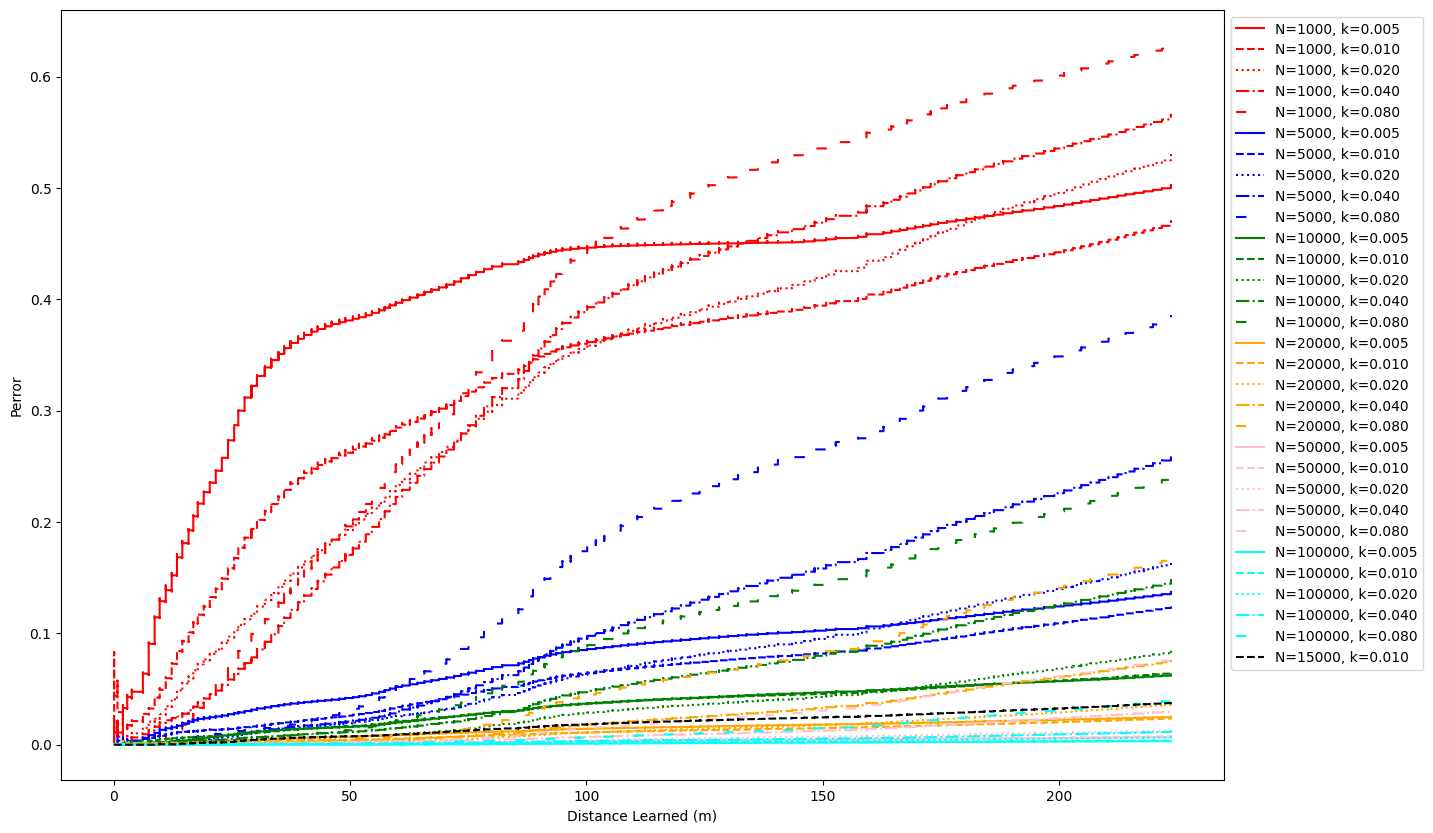

In [10]:


plt.figure(figsize=(15, 10))

# Plot the "learning_left" data.
xx = 'distance'
for i, (N, value, syn) in enumerate(param_pairs, start=1):
    key = f'df_{i}_t'
    if key in dfs:
        df = dfs[key]
        # Compute the multiplier (should equal one of 0.005, 0.01, etc.)
        multiplier = value / N
        color = color_map.get(N, 'black')
        linestyle = linestyle_map.get(multiplier, '-')
        label = f'N={N}, k={multiplier:.3f}'
        plt.plot(df[xx], df['Cumulative_Mean'], linestyle=linestyle, color=color, label=label)


plt.xlabel("Distance Learned (m)")
plt.ylabel("Perror")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig("../figures/memory_analysis/Perror_all_configs_with_legend.svg", format='svg')

plt.show()



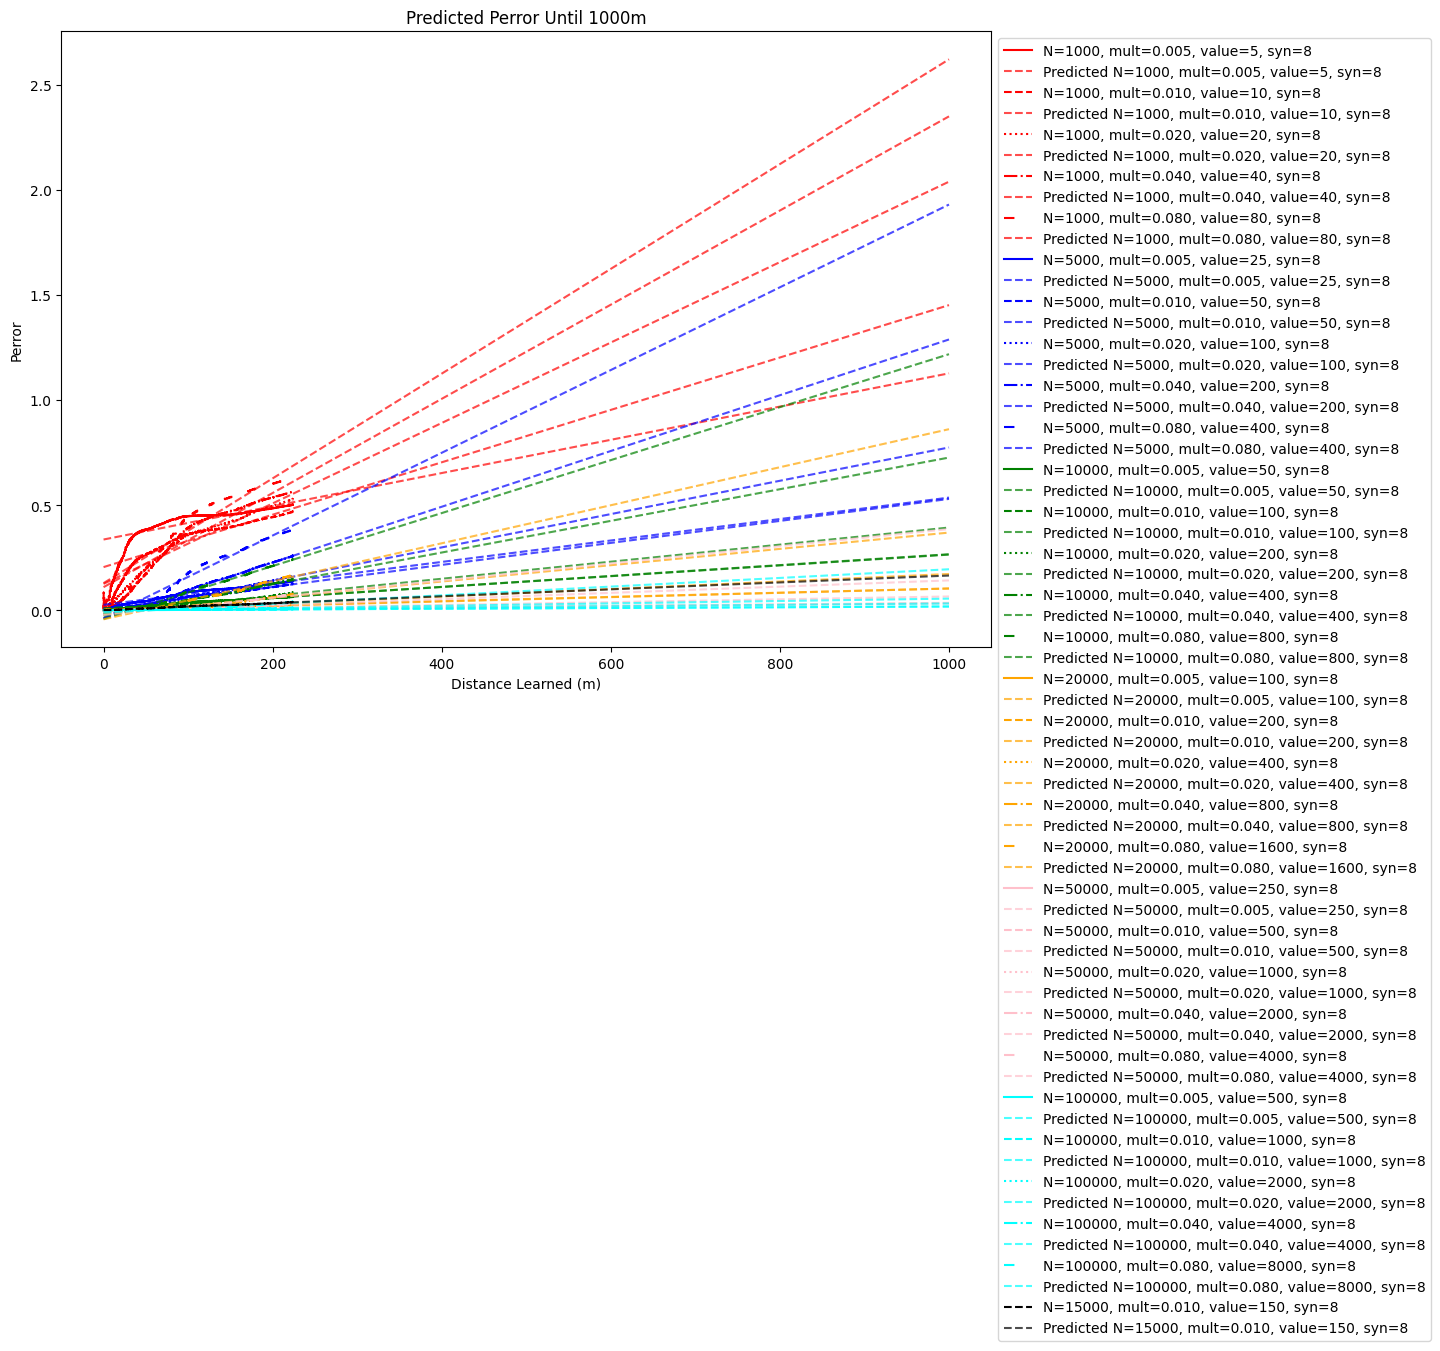

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(12, 8))

xx = 'distance'

for i, (N, value, syn) in enumerate(param_pairs, start=1):
    key = f'df_{i}_t'
    if key in dfs:
        df = dfs[key]
        # Compute the multiplier (should equal one of 0.005, 0.01, etc.)
        multiplier = value / N
        color = color_map.get(N, 'black')
        linestyle = linestyle_map.get(multiplier, '-')
        label = f'N={N}, mult={multiplier:.3f}, value={value:.0f}, syn={syn:.0f}'

        # Extract distance and cumulative mean values
        x = df[xx].values.reshape(-1, 1)  # Distance
        y = df['Cumulative_Mean'].values  # Error (Perror)
        
        # Fit a polynomial regression model
        degree = 1 # Adjust degree based on how the curve fits
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(x, y)

        # Predict error values from 0m to 1000m
        x_pred = np.linspace(0, 1000, 1000).reshape(-1, 1)  # Extended range
        y_pred = model.predict(x_pred)

        # Plot original data
        plt.plot(df[xx], df['Cumulative_Mean'], linestyle=linestyle, color=color, label=label)

        # Plot predicted curve
        plt.plot(x_pred, y_pred, linestyle='dashed', color=color, alpha=0.7, label=f'Predicted {label}')

plt.xlabel("Distance Learned (m)")
plt.ylabel("Perror")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Predicted Perror Until 1000m")
plt.show()


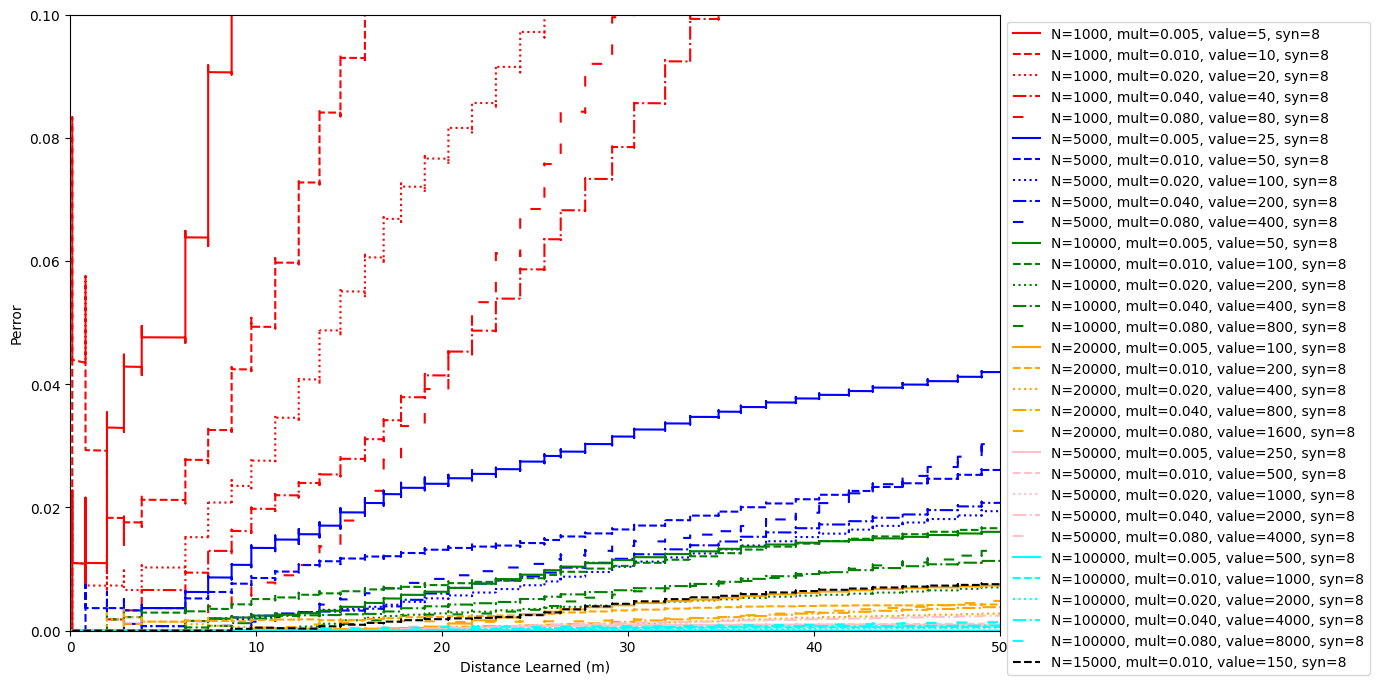

In [12]:
plt.figure(figsize=(12, 8))

# Plot the "learning_left" data.
xx = 'distance'
for i, (N, value, syn) in enumerate(param_pairs, start=1):
    key = f'df_{i}_t'
    if key in dfs:
        df = dfs[key]
        # Compute the multiplier (should equal one of 0.005, 0.01, etc.)
        multiplier = value / N
        color = color_map.get(N, 'black')
        linestyle = linestyle_map.get(multiplier, '-')
        label = f'N={N}, mult={multiplier:.3f}, value={value:.0f}, syn={syn:.0f}'
        plt.plot(df[xx], df['Cumulative_Mean'], linestyle=linestyle, color=color, label=label)

plt.ylim([0,0.1])
plt.xlim([0,50])

plt.xlabel("Distance Learned (m)")
plt.ylabel("Perror")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [13]:
df

,Unnamed: 0,lambda_L,lambda_R,it_learn,timestamp,x,y,theta,local_theta,heading_error,distance,index_image_nb,lambda_dif,Sign_Mismatch,Cumulative_Sum,Cumulative_Mean
0,0,0.000000,0.846667,10,1.057094,698420.44,4789687.5,28.90,-16.10,-45.0,0.12000,10.0,-0.846667,0,0,0.000000
1,1,0.026667,0.846667,10,1.057094,698420.44,4789687.5,28.90,-15.10,-44.0,0.12000,10.0,-0.820000,0,0,0.000000
2,2,0.053333,0.840000,10,1.057094,698420.44,4789687.5,28.90,-14.10,-43.0,0.12000,10.0,-0.786667,0,0,0.000000
3,3,0.046667,0.786667,10,1.057094,698420.44,4789687.5,28.90,-13.10,-42.0,0.12000,10.0,-0.740000,0,0,0.000000
4,4,0.026667,0.786667,10,1.057094,698420.44,4789687.5,28.90,-12.10,-41.0,0.12000,10.0,-0.760000,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847751,847751,0.053333,0.006667,1359,138.718480,698425.60,4789684.0,-52.47,-11.47,41.0,223.58391,1359.0,0.046667,0,32382,0.038197
847752,847752,0.046667,0.006667,1359,138.718480,698425.60,4789684.0,-52.47,-10.47,42.0,223.58391,1359.0,0.040000,0,32382,0.038197
847753,847753,0.053333,0.000000,1359,138.718480,698425.60,4789684.0,-52.47,-9.47,43.0,223.58391,1359.0,0.053333,0,32382,0.038197
847754,847754,0.066667,0.000000,1359,138.718480,698425.60,4789684.0,-52.47,-8.47,44.0,223.58391,1359.0,0.066667,0,32382,0.038197


In [14]:
df = dfs['df_31_t']
df = df[df['distance']< 55]

df1 = df[df["Cumulative_Mean"] == 0.01]
df1
# df.iloc[df[df["Cumulative_Mean"] == 0.01]]

,Unnamed: 0,lambda_L,lambda_R,it_learn,timestamp,x,y,theta,local_theta,heading_error,distance,index_image_nb,lambda_dif,Sign_Mismatch,Cumulative_Sum,Cumulative_Mean


/home/gat/mambaforge/envs/TheAntcarShuttle_analysis/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


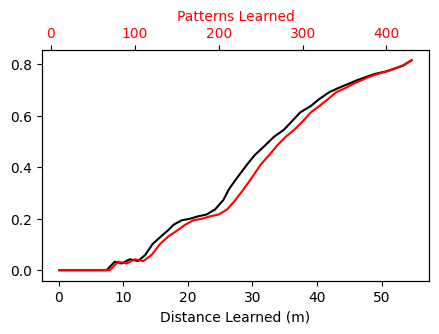

In [15]:
import statsmodels.api as sm
from scipy.interpolate import interp1d

fig, ax1 = plt.subplots(figsize=(5, 3))


# Plot the "learning_left" data.
xx = 'distance'
# key = f
df = dfs['df_31_t']
df = df[df['distance']< 55]

lowess_smoothed = sm.nonparametric.lowess(df['Cumulative_Mean'], df['distance'], frac=0.0001)  
lowess_smoothed_PAT = sm.nonparametric.lowess(df['Cumulative_Mean'], df['it_learn'], frac=0.0001)  

# frac controls the smoothing span; adjust as needed

# Plot on the primary axis
# ax1.plot(df["distance"], lowess_smoothed[:,1]*100, color='black', label='Cumulative Mean')

# Compute the multiplier (should equal one of 0.005, 0.01, etc.)
multiplier = value / 15000
color = color_map.get(15000, 'black')
linestyle = linestyle_map.get(multiplier, '-')
label = f'N={N}, mult={multiplier:.3f}, value={value:.0f}'
ax1.plot(df[xx], lowess_smoothed[:,1]*100, linestyle='-', color=color, label=label)

# Create a secondary x-axis on top for the distance in red
ax2 = ax1.twiny()
ax2.plot(df['it_learn'], lowess_smoothed[:,1]*100, linestyle='-', color='red', label='Cumulative Mean (Distance)')
ax2.set_xlabel('Patterns Learned', color='red')

# Customize the color of the upper x-axis ticks
ax2.tick_params(axis='x', labelcolor='red')
ax1.set_xlabel('Distance Learned (m)')
# ax1.set_xlim(0,50)
# ax1.set_xlim(0,50)

plt.ylabel("Perror")
plt.show()

Cumulative_Mean at 55 m: 0.008189461564858455


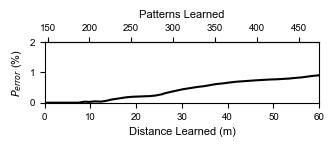

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.interpolate import interp1d

width_in_inches = 90 / 25.4
height_in_inches = 20 / 25.4

# sns.set_theme(style="ticks")
# Update Matplotlib rcParams to use the specified font and size globally
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,  # Set font size for x and y labels
    'axes.titlesize': 8,  # Set font size for titles
    'font.family': 'sans-serif',  # Ensure the global setting uses the desired font family
    'font.sans-serif': prop.get_name()  # Apply the specific font from the FontProperties object
})

# Example: Using one of your DataFrames (adjust key as needed)
key = f"df_{31}_t"
if key in dfs:
    df = dfs[key]

    fig, ax1 = plt.subplots(figsize=(width_in_inches, height_in_inches))

    lowess_smoothed = sm.nonparametric.lowess(df['Cumulative_Mean'], df['distance'], frac=0.0001)  
    # frac controls the smoothing span; adjust as needed

    # Plot on the primary axis
    ax1.plot(df["distance"], lowess_smoothed[:,1]*100, color='black', label='Cumulative Mean')
    # ax1.plot(df["distance"], df["Cumulative_Mean"], color='gray', label='Cumulative Mean')

    ax1.set_xlabel('Distance Learned (m)')
    ax1.set_ylabel(r'$P_{error}$ (%)')
    
    # Fit a linear relationship between distance and patterns learned:
    # it_learn = a * distance + b
    a, b = np.polyfit(df['distance'], df['it_learn'], 1)
    
    # Define the transformation functions.
    def forward(x):
        """Convert distance to patterns learned."""
        return a * x + b

    def inverse(x):
        """Convert patterns learned back to distance."""
        return (x - b) / a

    # Create a secondary x-axis that uses the forward/inverse mapping.
    ax2 = ax1.secondary_xaxis('top', functions=(forward, inverse))

    ax2.set_xlabel('Patterns Learned')

    # Set the x-limits for ax1 (the primary axis).
    ax1.set_xlim(0, 60)
    ax1.set_ylim(0, 2)
    # With the secondary_xaxis, ax2's limits will automatically be set to
    # forward(0) and forward(55), so they correspond to the zoomed region of ax1.

    # Create an interpolation function.
    interp_func = interp1d(df["distance"], df["Cumulative_Mean"], kind='linear', fill_value='extrapolate')

    # Estimate the Cumulative_Mean at 55 m.
    value_at_55 = interp_func(55)
    print("Cumulative_Mean at 55 m:", value_at_55)
    
    plt.show()

fig.savefig("../figures/memory_analysis/Perror_distance_patterns_xp_out_day3", format='svg')


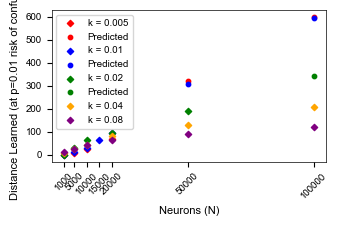

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Set figure dimensions in inches
width_in_inches = 90 / 25.4
height_in_inches = 50 / 25.4

# Update Matplotlib rcParams for consistent font and style
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'font.family': 'sans-serif',
    'font.sans-serif': prop.get_name()  # using your FontProperties object
})

# Define colors for each multiplier value
multiplier_color_map = {
    0.005: 'red',
    0.01: 'blue',
    0.02: 'green',
    0.04: 'orange',
    0.08: 'purple'
}

# Prepare a dictionary to store both measured (real) and predicted data
scatter_data = {
    mult: {'real_N': [], 'real_distance': [], 'pred_N': [], 'pred_distance': []}
    for mult in multiplier_color_map.keys()
}

target = 0.01  # Cumulative_Mean threshold

# Loop over your parameter pairs (assumes param_pairs is defined)
for i, (N, value, syn) in enumerate(param_pairs, start=1):
    key = f"df_{i}_t"  # key for the corresponding DataFrame in dfs
    if key in dfs:
        df = dfs[key]
        # Calculate multiplier and round to avoid float issues
        multiplier = round(value / N, 3)
        
        if multiplier in scatter_data:
            # Check if measured data reaches/exceeds the target
            mask_measured = df["Cumulative_Mean"] >= target
            if mask_measured.any():
                # Use the first measured distance that meets the condition
                distance_val = df[mask_measured]["distance"].iloc[0]
                scatter_data[multiplier]['real_N'].append(N)
                scatter_data[multiplier]['real_distance'].append(distance_val)
            else:
                # Use a simple polynomial regression (degree 1) for prediction
                x = df['distance'].values.reshape(-1, 1)
                y = df['Cumulative_Mean'].values
                degree = 1  # Adjust degree as needed
                model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
                model.fit(x, y)
                
                # Predict on a range from 0 to 2000m
                x_pred = np.linspace(0, 2000, 2000).reshape(-1, 1)
                y_pred = model.predict(x_pred)
                mask_pred = y_pred >= target
                if mask_pred.any():
                    distance_val = x_pred[mask_pred][0]
                else:
                    distance_val = -1  # or choose a default value
                scatter_data[multiplier]['pred_N'].append(N)
                scatter_data[multiplier]['pred_distance'].append(distance_val)

# Create the scatter plot
plt.figure(figsize=(width_in_inches, height_in_inches))
for mult, data in scatter_data.items():
    color = multiplier_color_map[mult]
    # Plot real data with diamond markers
    if data['real_N']:
        plt.scatter(data['real_N'], data['real_distance'],
                    color=color, marker='D',  # 'D' is diamond marker
                    label=f"k = {mult}", s=10)
    # Plot predicted data with circle markers
    if data['pred_N']:
        plt.scatter(data['pred_N'], data['pred_distance'],
                    color=color, marker='o',  # 'o' is circle marker
                    label=f"Predicted", s=10)

plt.xlabel("Neurons (N)")
plt.ylabel("Distance Learned (at p=0.01 risk of confusion)")
plt.legend(loc="best")

# Set the x-axis ticks to the unique values of N used in the plots
all_N = []
for data in scatter_data.values():
    all_N.extend(data['real_N'])
    all_N.extend(data['pred_N'])
unique_N = sorted(set(all_N))
plt.xticks(unique_N, unique_N, rotation=45)

# Reduce the linewidth of the box (axes spines)
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.show()


Cumulative_Mean at 450 m: 0.0
Cumulative_Mean at 54 m: 0.007983107453203294


/home/gat/mambaforge/envs/TheAntcarShuttle_analysis/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


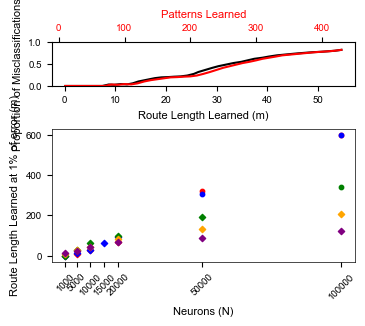

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy.interpolate import interp1d

# Set overall figure width in inches.
width_in_inches = 90 / 25.4

# We'll define a total height and then use height ratios.
total_height = 80 / 25.4  # Total height (in inches) for the combined figure

# Update Matplotlib rcParams for consistent font and style
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'font.family': 'sans-serif',
    'font.sans-serif': prop.get_name()  # using your FontProperties object
})

# Create a figure with two subplots (vertical stack) with height ratios
# Here, the first subplot (LOWESS) is 1/3 of the total height and the scatter plot is 2/3.
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(width_in_inches, total_height),
                                gridspec_kw={'height_ratios': [1, 3]},
                                constrained_layout=True)

# ===========================
# Top Subplot: LOWESS and Secondary Axis
# ===========================
key = f"df_{31}_t"
if key in dfs:
    # Plot the "learning_left" data.
    xx = 'distance'
    # key = f
    df = dfs['df_31_t']
    interp_func = interp1d(df["distance"], df["Cumulative_Mean"], kind='linear', fill_value='extrapolate')
    interp_func = interp1d(df["it_learn"], df["Cumulative_Mean"], kind='linear', fill_value='interpolate')

    value_at_55 = interp_func(65)

    print("Cumulative_Mean at 450 m:", value_at_55)

    df = df[df['distance']< 55]

    lowess_smoothed = sm.nonparametric.lowess(df['Cumulative_Mean'], df['distance'], frac=0.0001)  
    lowess_smoothed_PAT = sm.nonparametric.lowess(df['Cumulative_Mean'], df['it_learn'], frac=0.0001)  

    # frac controls the smoothing span; adjust as needed

    # Plot on the primary axis
    # ax1.plot(df["distance"], lowess_smoothed[:,1]*100, color='black', label='Cumulative Mean')

    # Compute the multiplier (should equal one of 0.005, 0.01, etc.)
    multiplier = value / 15000
    color = color_map.get(15000, 'black')
    linestyle = linestyle_map.get(multiplier, '-')
    label = f'N={N}, mult={multiplier:.3f}, value={value:.0f}'

    ax1.plot(df[xx], lowess_smoothed[:,1]*100, linestyle='-', color=color, label=label,zorder=1)

    # Create a secondary x-axis on top for the distance in red
    ax2 = ax1.twiny()
    ax2.plot(df['it_learn'], lowess_smoothed[:,1]*100, linestyle='-', color='red', label='Cumulative Mean (Distance)',zorder=10)

    ax2.set_xlabel('Patterns Learned', color='red')

    # Customize the color of the upper x-axis ticks
    ax2.tick_params(axis='x', labelcolor='red')
    ax1.set_xlabel('Route Length Learned (m)')
    # ax1.set_xlim(0,50)
    # ax1.set_xlim(0,50)
    
    # Optionally, interpolate Cumulative_Mean at 55 m and print the value
    interp_func = interp1d(df["distance"], df["Cumulative_Mean"], kind='linear', fill_value='extrapolate')
    value_at_55 = interp_func(54)
    print("Cumulative_Mean at 54 m:", value_at_55)
    
    # Reduce the linewidth of the spines for ax1
    for spine in ax1.spines.values():
        spine.set_linewidth(0.5)

# ===========================
# Bottom Subplot: Scatter Plot (log x-axis)
# ===========================
# Define colors for each multiplier value
multiplier_color_map = {
    0.005: 'red',
    0.01: 'blue',
    0.02: 'green',
    0.04: 'orange',
    0.08: 'purple'
}

# Dictionary to store measured (real) and predicted data
scatter_data = {
    mult: {'real_N': [], 'real_distance': [], 'pred_N': [], 'pred_distance': []}
    for mult in multiplier_color_map.keys()
}

target = 0.01  # Cumulative_Mean threshold

# Process each parameter pair (assumes param_pairs is defined)
for i, (N, value, syn) in enumerate(param_pairs, start=1):
    key = f"df_{i}_t"
    if key in dfs:
        df = dfs[key]
        multiplier = round(value / N, 3)
        
        if multiplier in scatter_data:
            mask_measured = df["Cumulative_Mean"] >= target
            if mask_measured.any():
                distance_val = df[mask_measured]["distance"].iloc[0]
                scatter_data[multiplier]['real_N'].append(N)
                scatter_data[multiplier]['real_distance'].append(distance_val)
            else:
                x = df['distance'].values.reshape(-1, 1)
                y = df['Cumulative_Mean'].values
                degree = 1
                model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
                model.fit(x, y)
                
                x_pred = np.linspace(0, 2000, 2000).reshape(-1, 1)
                y_pred = model.predict(x_pred)
                mask_pred = y_pred >= target
                if mask_pred.any():
                    distance_val = x_pred[mask_pred][0]
                else:
                    distance_val = -1
                scatter_data[multiplier]['pred_N'].append(N)
                scatter_data[multiplier]['pred_distance'].append(distance_val)

# Plot the scatter data on ax2
for mult, data in scatter_data.items():
    color = multiplier_color_map[mult]
    if data['real_N']:
        ax3.scatter(data['real_N'], data['real_distance'],
                    color=color, marker='D', label=f"k = {mult}", s=10)
    if data['pred_N']:
        ax3.scatter(data['pred_N'], data['pred_distance'],
                    color=color, marker='o', label="Predicted", s=10)

ax3.set_xlabel("Neurons (N)")
ax3.set_ylabel(r"Route Length Learned at 1% of error (m)")
# ax3.legend(loc="best")

ax1.set_ylim([0,1])
# ax1.set_ylabel(r"$Pl_{error} (\%)$")
ax1.set_ylabel("Proportion of Misclassifications (%)")

# Set x-axis to logarithmic scale on ax2
# ax2.set_xscale('log')
# ax3.set_yscale('log')

# Set x-ticks for ax2 using unique N values, rotated by 45°
all_N = []
for data in scatter_data.values():
    all_N.extend(data['real_N'])
    all_N.extend(data['pred_N'])
unique_N = sorted(set(all_N))
ax3.set_xticks(unique_N)
ax3.set_xticklabels(unique_N, rotation=45)

# Reduce the linewidth of the spines for ax2
for spine in ax3.spines.values():
    spine.set_linewidth(0.5)

# Save the figure as an SVG file
fig.savefig("../figures/memory_analysis/Perror_distance_patterns_xp_out_day3.svg", format='svg')
plt.show()


/home/gat/mambaforge/envs/TheAntcarShuttle_analysis/lib/python3.9/site-packages/numpy/ma/core.py:2826: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  _data = np.array(data, dtype=dtype, copy=copy,


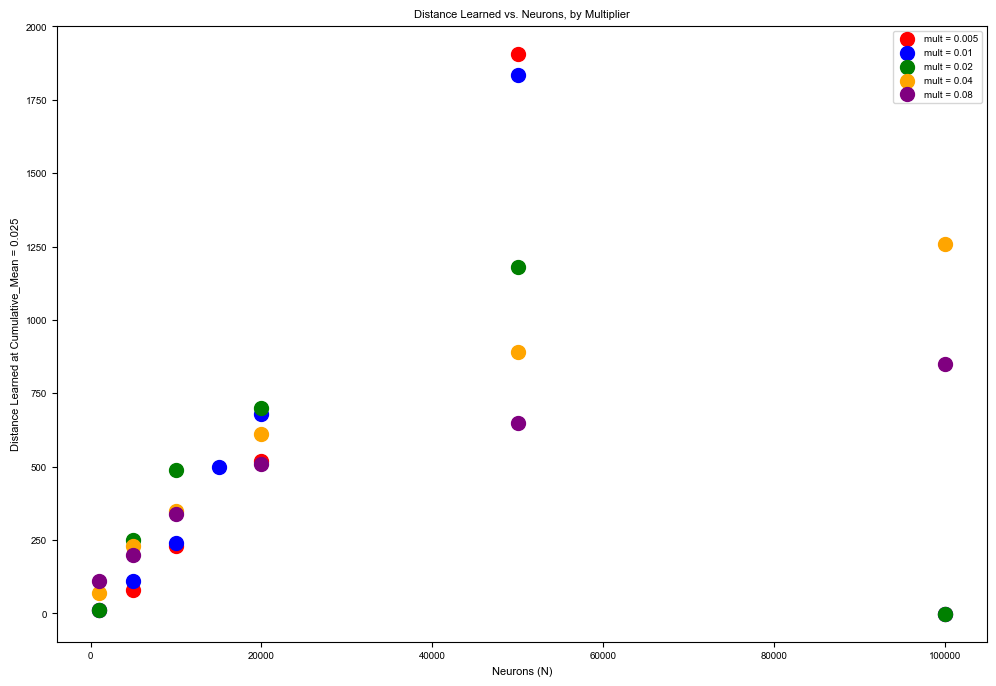

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Define a color for each multiplier.
multiplier_color_map = {
    0.005: 'red',
    0.01: 'blue',
    0.02: 'green',
    0.04: 'orange',
    0.08: 'purple'
}

# Prepare a dictionary to accumulate points for each multiplier.
# We'll use the multiplier (rounded) as keys.
scatter_data = {mult: {'N': [], 'it_learn': []} for mult in multiplier_color_map.keys()}

target = 0.01  # The Cumulative_Mean threshold

# Loop over the parameter pairs
for i, (N, value, syn) in enumerate(param_pairs, start=1):
    key = f"df_{i}_t"  # use the test DataFrame (adjust if needed)
    if key in dfs:
        df = dfs[key]
        # Calculate the multiplier (rounding to avoid float imprecision)
        multiplier = round(value / N, 3)
        
        # Check if measured data reaches/exceeds the target
        mask_measured = df["Cumulative_Mean"] >= target
        if mask_measured.any():
            # Get the distance from the first row that meets the condition
            distance_val = df[mask_measured]["it_learn"].iloc[0]
        else:
            # Fit a polynomial regression model because measured data doesn't reach the target
            x = df['it_learn'].values.reshape(-1, 1)  # Distance values
            y = df['Cumulative_Mean'].values         # Cumulative_Mean values
            
            degree = 1  # Adjust degree based on how the curve fits
            model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
            model.fit(x, y)

            # Predict error values from 0m to 500m (or adjust range as needed)
            x_pred = np.linspace(0, 2000, 2000).reshape(-1, 1)
            y_pred = model.predict(x_pred)

            mask_pred = y_pred >= target
            if mask_pred.any():
                # Take the first predicted distance that meets the target
                distance_val = x_pred[mask_pred][0]
            else:
                # If even the predicted values don't reach the target, you can choose to skip
                # or assign a default value (e.g., 500).
                distance_val = -1
        
        # Append the distance value and N to the corresponding multiplier group
        if multiplier in scatter_data:
            scatter_data[multiplier]['N'].append(N)
            scatter_data[multiplier]['it_learn'].append(distance_val)
        else:
            # Optionally, add new multiplier keys or skip
            pass

# Create the scatter plot
plt.figure(figsize=(12, 8))
for mult, data in scatter_data.items():
    plt.scatter(data['N'], data['it_learn'], color=multiplier_color_map[mult], 
                label=f"mult = {mult}", s=100)  # s sets the marker size

plt.xlabel("Neurons (N)")
plt.ylabel("Distance Learned at Cumulative_Mean = 0.025")
plt.title("Distance Learned vs. Neurons, by Multiplier")
plt.legend(loc="best")
plt.show()
